# 03b — SegFormer-B2
**Paper:** Xie et al., NeurIPS 2021. Adaptación AI4MARS: Ankithac45/Semantic-Segmentation-on-Martian-Terrain

## 0. Configuración

In [2]:
import sys; sys.path.append('.')
import torch, torch.nn as nn, torch.nn.functional as F
import pandas as pd, numpy as np
from mars_utils_fast import (
    set_seed, get_or_create_split, build_dataloaders,
    run_multi_seed, append_benchmark_results,
    visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX, SEED
)

set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
MODEL_NAME = "segformer_b2"


Device: cuda


## 1. Dataset

In [3]:
df = pd.read_csv("processed/manifest_256.csv")
df_train, df_val, df_test = get_or_create_split(df)
train_loader, val_loader, test_loader = build_dataloaders(
    df_train, df_val, df_test, batch_size=8, num_workers=0
)


✅ Split cargado desde processed\split_indices.pkl
Train: 16074 {'MSL': 15901, 'MER': 173}
Val  :  3443 {'MSL': 3443}
Test :  3448 {'MSL': 3448}


## 2. Modelo — SegFormer-B2 via HuggingFace
MiT-B2 encoder + All-MLP decoder. Preentrenado en ImageNet-1K.

In [4]:
try:
    from transformers import SegformerForSemanticSegmentation, SegformerConfig
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False
    print("transformers no instalado. Ejecuta: pip install transformers")

class SegFormerWrapper(nn.Module):
    """
    Wrapper de SegFormer HuggingFace para compatibilidad con el pipeline.
    La salida de SegFormer es resolución H/4. Se hace upsample a H.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        config = SegformerConfig.from_pretrained("nvidia/mit-b2")
        config.num_labels = num_classes
        config.id2label   = {i: n for i, n in enumerate(["soil","bedrock","sand","big_rock"])}
        config.label2id   = {n: i for i, n in enumerate(["soil","bedrock","sand","big_rock"])}
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/mit-b2", config=config, ignore_mismatched_sizes=True, use_safetensors=True 
        )

    def forward(self, x):
        out    = self.model(pixel_values=x)
        logits = out.logits  # [B, C, H/4, W/4]
        return F.interpolate(logits, size=x.shape[-2:],
                             mode="bilinear", align_corners=False)

def build_segformer():
    return SegFormerWrapper(NUM_CLASSES)

model = build_segformer().to(device)
params_M = count_parameters(model)
print(f"Parámetros: {params_M:.2f}M")

with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out   = model(dummy)
    print(f"Output: {out.shape}")


c:\Users\User\miniconda3\envs\pytorch_gpu\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--nvidia--mit-b2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 a

Parámetros: 27.35M
Output: torch.Size([2, 4, 256, 256])


## 3. Entrenamiento (3 seeds)
AdamW + CosineAnnealingLR, loss CE con ignore_index=255

In [5]:
import torch.optim as optim

def criterion_fn():
    return nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

def optimizer_fn(params):
    return optim.AdamW(params, lr=6e-5, weight_decay=0.01, betas=(0.9, 0.999))

def scheduler_fn(opt):
    return optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30, eta_min=1e-6)

summary = run_multi_seed(
    model_fn     = build_segformer,
    df_train=df_train, df_val=df_val, df_test=df_test,
    criterion_fn = criterion_fn,
    optimizer_fn = optimizer_fn,
    scheduler_fn = scheduler_fn,
    model_name   = MODEL_NAME,
    device       = device,
    seeds        = [42, 123, 7],
    num_epochs   = 80, patience=10,
    batch_size=10, num_workers=4, n_per_mission=700
)



──────────────────────────────────────────────────
  Seed 42 | segformer_b2


c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
Some weights of SegformerForSemanticSegmentation were not initialized fr


  segformer_b2_seed42 | device=cuda | AMP=True
Ep   1/80 | loss=0.5631 mIoU=0.5107 | val=0.6526 | rock=0.0014
Ep   2/80 | loss=0.2821 mIoU=0.6228 | val=0.6475 | rock=0.0065
Ep   3/80 | loss=0.2344 mIoU=0.6588 | val=0.6977 | rock=0.1069
Ep   4/80 | loss=0.2001 mIoU=0.6928 | val=0.7022 | rock=0.0812
Ep   5/80 | loss=0.1654 mIoU=0.7073 | val=0.7342 | rock=0.2099
Ep   6/80 | loss=0.1605 mIoU=0.7455 | val=0.7463 | rock=0.2665
Ep   7/80 | loss=0.1544 mIoU=0.7744 | val=0.8117 | rock=0.5766
Ep   8/80 | loss=0.1256 mIoU=0.7894 | val=0.8144 | rock=0.5333
Ep   9/80 | loss=0.1082 mIoU=0.7986 | val=0.8172 | rock=0.5613
Ep  10/80 | loss=0.1093 mIoU=0.8232 | val=0.8358 | rock=0.5791
Ep  11/80 | loss=0.0984 mIoU=0.7934 | val=0.8324 | rock=0.6047
Ep  12/80 | loss=0.0819 mIoU=0.8063 | val=0.8340 | rock=0.6078
Ep  13/80 | loss=0.0964 mIoU=0.8211 | val=0.8238 | rock=0.5768
Ep  14/80 | loss=0.0767 mIoU=0.8620 | val=0.8261 | rock=0.5713
Ep  15/80 | loss=0.0663 mIoU=0.8564 | val=0.8458 | rock=0.6283
Ep  16/

c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
Some weights of SegformerForSemanticSegmentation were not initialized fr


  segformer_b2_seed123 | device=cuda | AMP=True
Ep   1/80 | loss=0.5860 mIoU=0.5106 | val=0.6534 | rock=0.0458
Ep   2/80 | loss=0.2721 mIoU=0.6436 | val=0.6111 | rock=0.0195
Ep   3/80 | loss=0.2260 mIoU=0.6653 | val=0.6726 | rock=0.0040
Ep   4/80 | loss=0.2168 mIoU=0.6826 | val=0.7059 | rock=0.4009
Ep   5/80 | loss=0.1769 mIoU=0.7066 | val=0.7003 | rock=0.1126
Ep   6/80 | loss=0.1377 mIoU=0.7376 | val=0.6382 | rock=0.0527
Ep   7/80 | loss=0.1419 mIoU=0.7473 | val=0.7875 | rock=0.4358
Ep   8/80 | loss=0.1261 mIoU=0.7752 | val=0.8335 | rock=0.5866
Ep   9/80 | loss=0.1290 mIoU=0.7810 | val=0.8225 | rock=0.5957
Ep  10/80 | loss=0.1121 mIoU=0.8265 | val=0.8011 | rock=0.5050
Ep  11/80 | loss=0.1004 mIoU=0.8136 | val=0.8249 | rock=0.5881
Ep  12/80 | loss=0.0893 mIoU=0.8300 | val=0.8424 | rock=0.5847
Ep  13/80 | loss=0.0908 mIoU=0.8347 | val=0.8243 | rock=0.5885
Ep  14/80 | loss=0.0702 mIoU=0.8622 | val=0.7884 | rock=0.4650
Ep  15/80 | loss=0.0662 mIoU=0.8713 | val=0.8546 | rock=0.6386
Ep  16

c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
c:\Users\User\Documents\DeepLearning\ai4mars-dataset-merged-0.6\mars_utils_fast.py:139: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("mission", group_keys=False)
Some weights of SegformerForSemanticSegmentation were not initialized fr


  segformer_b2_seed7 | device=cuda | AMP=True
Ep   1/80 | loss=0.5284 mIoU=0.5166 | val=0.6017 | rock=0.0000
Ep   2/80 | loss=0.3034 mIoU=0.6204 | val=0.6417 | rock=0.0437
Ep   3/80 | loss=0.2394 mIoU=0.6776 | val=0.6884 | rock=0.0471
Ep   4/80 | loss=0.2272 mIoU=0.6843 | val=0.6791 | rock=0.3191
Ep   5/80 | loss=0.1852 mIoU=0.7247 | val=0.6787 | rock=0.0336
Ep   6/80 | loss=0.1668 mIoU=0.7287 | val=0.7796 | rock=0.4233
Ep   7/80 | loss=0.1428 mIoU=0.7664 | val=0.7110 | rock=0.0999
Ep   8/80 | loss=0.1322 mIoU=0.7725 | val=0.7537 | rock=0.2742
Ep   9/80 | loss=0.1051 mIoU=0.7752 | val=0.7955 | rock=0.4641
Ep  10/80 | loss=0.0973 mIoU=0.7978 | val=0.7816 | rock=0.4750
Ep  11/80 | loss=0.0949 mIoU=0.7886 | val=0.8283 | rock=0.5562
Ep  12/80 | loss=0.0995 mIoU=0.8338 | val=0.7929 | rock=0.4208
Ep  13/80 | loss=0.0930 mIoU=0.8142 | val=0.8138 | rock=0.5102
Ep  14/80 | loss=0.0758 mIoU=0.8539 | val=0.8281 | rock=0.5378
Ep  15/80 | loss=0.0733 mIoU=0.8348 | val=0.8432 | rock=0.5900
Ep  16/8

## 4. Guardado y Visualización

In [ ]:
append_benchmark_results(
    model_name=MODEL_NAME, best_epoch=summary["best_epoch_mean"],
    val_miou=summary["mIoU_mean"], test_miou=summary["mIoU_mean"],
    test_miou_std=summary["mIoU_std"], test_miou_ci95=summary["mIoU_ci95"],
    test_acc=summary["pixel_acc_mean"],
    iou_soil=summary["iou_soil_mean"], iou_bedrock=summary["iou_bedrock_mean"],
    iou_sand=summary["iou_sand_mean"], iou_bigrock=summary["iou_big_rock_mean"],
    params_M=params_M, train_time_s=summary["train_time_mean"],
)
best_model = build_segformer().to(device)
ckpt = torch.load(f"checkpoints/{MODEL_NAME}_seed42_best.pth", map_location=device)
best_model.load_state_dict(ckpt["model_state"])
visualize_predictions(best_model, df_test, device, n=5,
    save_path=f"results/{MODEL_NAME}_predictions.png")
print(f"mIoU: {summary['mIoU_mean']:.4f} ± {summary['mIoU_std']:.4f}")


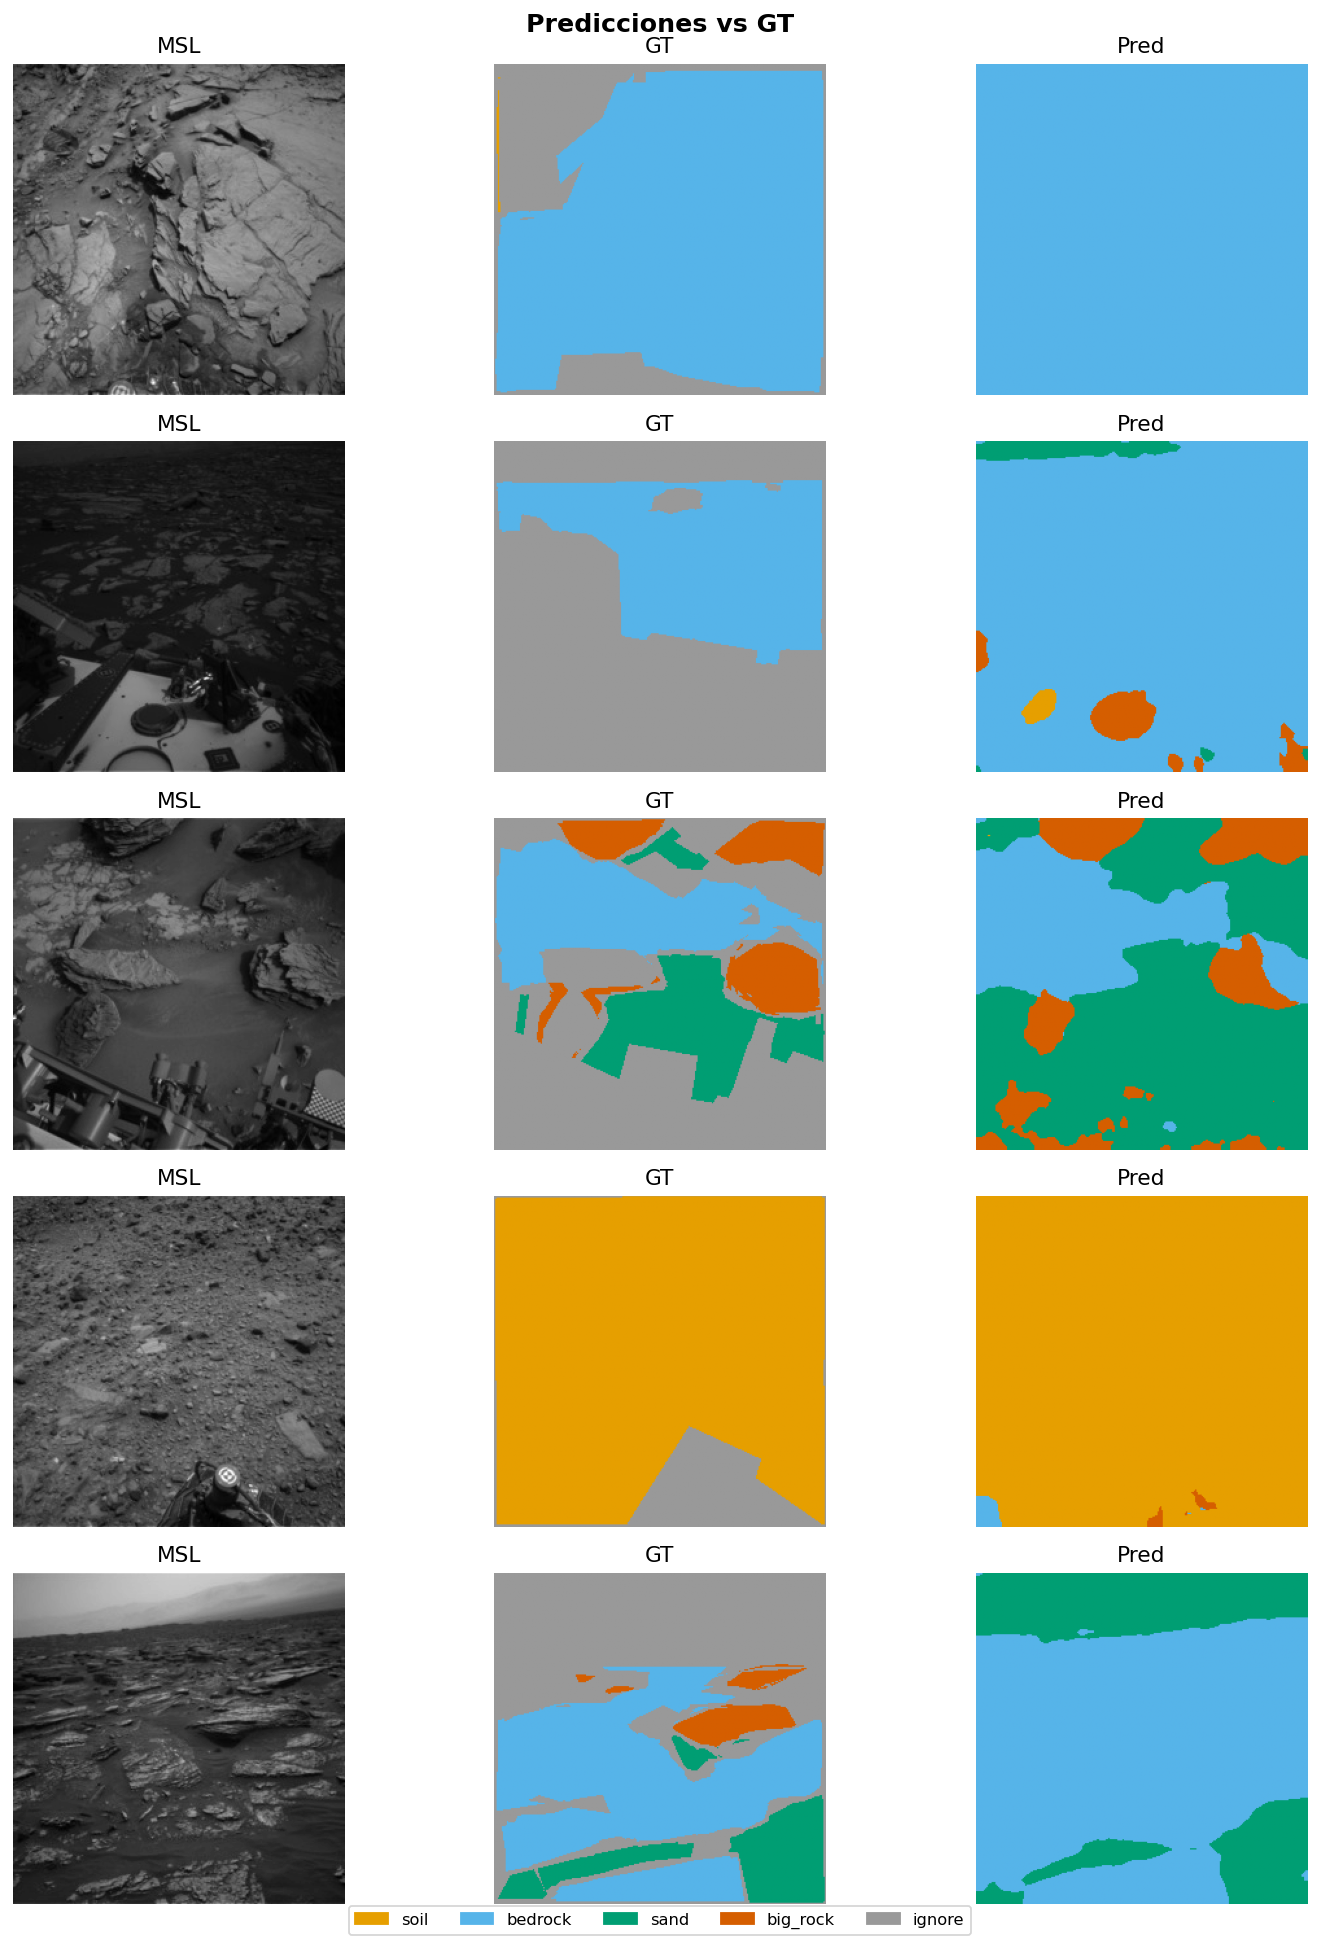